In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

import matplotlib.pyplot as plt
import seaborn as sns
from src import *
import numpy as np


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathptmx}",  # Times Roman
    "hatch.linewidth": 3.0,
})
sns.set_context("paper",font_scale=1.5)
sns.set_palette("pastel")

# 1. Simulate population

In [2]:
### 1. initiate some params
# bounds
a0_pop_min=10
a0_pop_max=20
log_mbh_min = 6
log_mbh_max = 8

# time,rate,pop size
t=1
tR=1
popN=10000
rates = np.logspace(-1,1,50)

### 2. simulate input data as uniform
# high z pop
np.random.seed(0)
a0_pop = np.random.uniform(a0_pop_min,a0_pop_max,popN)
log_mbh_sec_pop = np.random.uniform(log_mbh_min,log_mbh_max,popN)
mbh_pop= 10**log_mbh_sec_pop
q_pop = np.random.uniform(1,100,popN)

# low z pop
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
ap = np.linspace(0,a0_pop.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obs = scp_kde(a0_pop,ap,return_func=True)
p_a0_obs_val = p_a0_obs(ap)
#predict p(af) at different rates
# p_af_preds = paf_analytic_allrates_mbhrange(p_a0_obs,a0_pop_min,a0_pop_max,
#                                             log_mbh_min, log_mbh_max,
#                                             t,af_grid=ap,
#                                             Naf=50,Na0=2000,uniform=True,
#                                             rates=np.logspace(-1,1,5))

### unit tests

/home/insepien/dftime/src/pa.py:29: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:30: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/src/pa.py:31: RuntimeWarning: invalid value encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)


(200, 2000, 50)


''

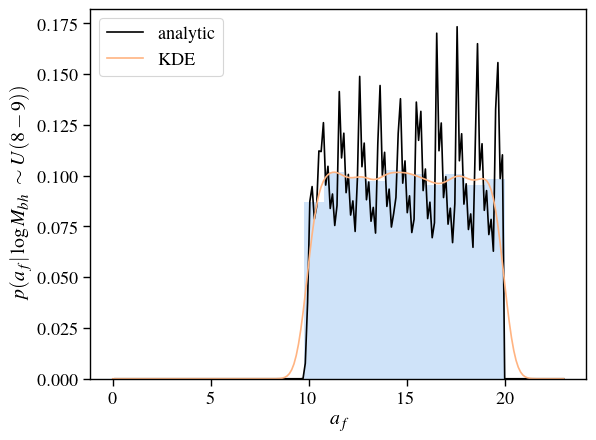

In [4]:
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)
_,paf = p_af_sigma_a0_mbhrange_unif_fast(a0_pop_min,a0_pop_max,log_mbh_min,log_mbh_max,t,tR,None)
plt.plot(_,paf,color='k',label='analytic')
plt.hist(af_pop,density=True,alpha=0.5)
# plt.plot(ap,p_a0_obs_val,c='b',alpha=0.5)
plt.plot(ap,scp_kde(af_pop,ap),label='KDE')
plt.xlabel("$a_f$")
plt.ylabel("$p({a_f}|\log{M_{bh}}~\sim U(8-9))$")
plt.legend()
;

NameError: name 'p_af_preds' is not defined

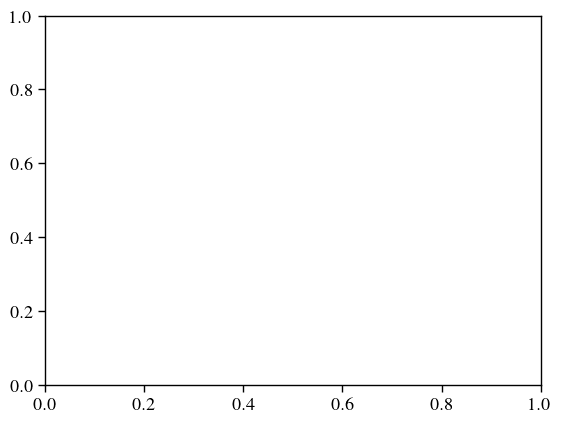

In [5]:
norm = mcolors.LogNorm(vmin=rates.min(), vmax=rates.max())
cmap = mycmap()

fig,ax = plt.subplots()

[ax.plot(ap,p,c=cmap(norm(k))) for k,p in p_af_preds.items()]
ax.plot(ap,scp_kde(af_pop,ap))
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax)

ax.plot(ap,p_a0_obs_val,label='a0 pop',c='grey',linestyle='--')
ax.plot(ap,scp_kde(af_pop,ap),label='af pop',c='k')
# ax.hist(af_pop, density=True,alpha=0.1,color='k')
ax.legend();

# 2. Sample from population

In [14]:
# 1. Define a large batch size (e.g., 10,000)
batch_size = 10000 
reso = 0.1
np.random.seed(0)
# 2. Generate arrays for all candidates at once
a = np.random.uniform(a0_pop_min, a0_pop_max, batch_size)
q = np.random.uniform(1, 90, batch_size)
z = 0.2#np.random.uniform(0.18, 0.2, batch_size)
pobs = psel(a, z, q, reso) #* 1/10*1/99
u = np.random.uniform(0, pobs.max(), batch_size)

# 3. Apply the mask
mask = u < pobs

# 4. Filter
accepted_a = a[mask]
accepted_q = q[mask]
accepted_pobs = pobs[mask]


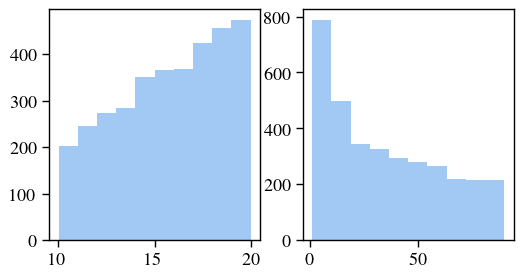

In [18]:
fig,ax = plt.subplots(1,2,figsize=(6,3))
ax[0].hist(accepted_a)
ax[1].hist(accepted_q);

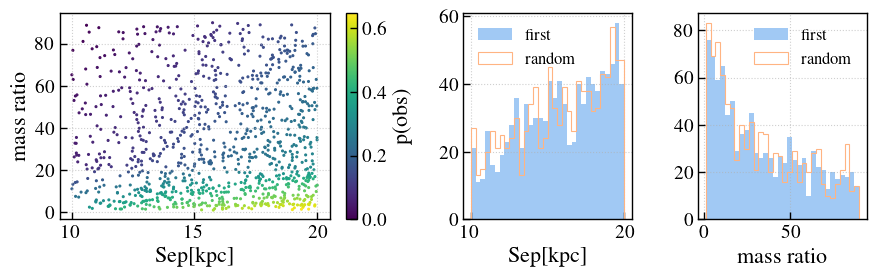

In [39]:
fig,ax = plt.subplots(1,3,figsize=(9,3),width_ratios=[2,1,1])
np.random.seed(0)
Nobs = 1000
ax[0].scatter(accepted_a[:Nobs], accepted_q[:Nobs],c=accepted_pobs[:Nobs],cmap='viridis',s=2)
ax[0].set_xlabel("Sep[kpc]")
ax[0].set_ylabel("mass ratio")

ax[1].set_xlabel("Sep[kpc]")
ax[2].set_xlabel("mass ratio")

ax[1].hist(accepted_a[:Nobs],label='first')
ax[1].hist(np.random.choice(accepted_a,Nobs),histtype='step',label='random');
ax[1].legend()

ax[2].hist(accepted_q[:Nobs],label='first')
ax[2].hist(np.random.choice(accepted_q,Nobs),histtype='step',label='random');
ax[2].legend()

norm = mcolors.Normalize(vmin=0, vmax=pobs.max())
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'),ax=ax[0],label='p(obs)')

fig.tight_layout();

# 3. Correct for selection bias

In [19]:
import scipy.stats as st
from figaro.mixture import DPGMM, HDPGMM
from figaro.utils import get_priors
from tqdm import tqdm
from figaro.plot import plot_median_cr, plot_multidim

In [145]:
Nobs = 100
# generate more than the observe size to remove the ones with negative values
a0_samp = accepted_a[:Nobs]
q_samp = accepted_q[:Nobs]
samples_aq = np.stack([a0_samp,q_samp],axis=1)


## single param DPGMM

In [22]:
a_min = a0_pop_min-3
a_max = a0_pop_max+3
bounds = [a_min, a_max]
a0_samp = np.random.uniform(a0_pop_min,a0_pop_max,100)
prior_pars = get_priors(bounds = bounds, samples = a0_samp)

mixdp = DPGMM(bounds, prior_pars = prior_pars)

ndraws = 1000
draw_1d = lambda n: mixdp.density_from_samples(a0_samp)
draws = Parallel(n_jobs=-1)(delayed(draw_1d)(n) for n in tqdm(range(ndraws)))

100%|██████████| 1000/1000 [01:26<00:00, 11.61it/s]


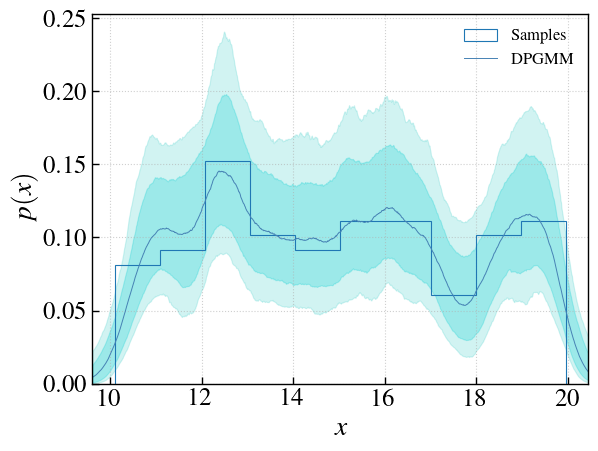

In [23]:
fig = plot_median_cr(draws,
               samples  = a0_samp,
               save     = False,
               show     = True
               )

## 2d DPGMM

In [82]:
q_min = 0
q_max = 110

bounds = [[a_min, a_max],[q_min,q_max]]
mix_2d = DPGMM(bounds, prior_pars = get_priors(bounds, samples_aq, scale = 3))

n_draws = 10
draws_2d_func = lambda n: mix_2d.density_from_samples(samples_aq)
draws_2d = Parallel(n_jobs=-1)(delayed(draws_2d_func)(n) for n in tqdm(range(n_draws)))

100%|██████████| 10/10 [00:00<00:00, 770.86it/s]


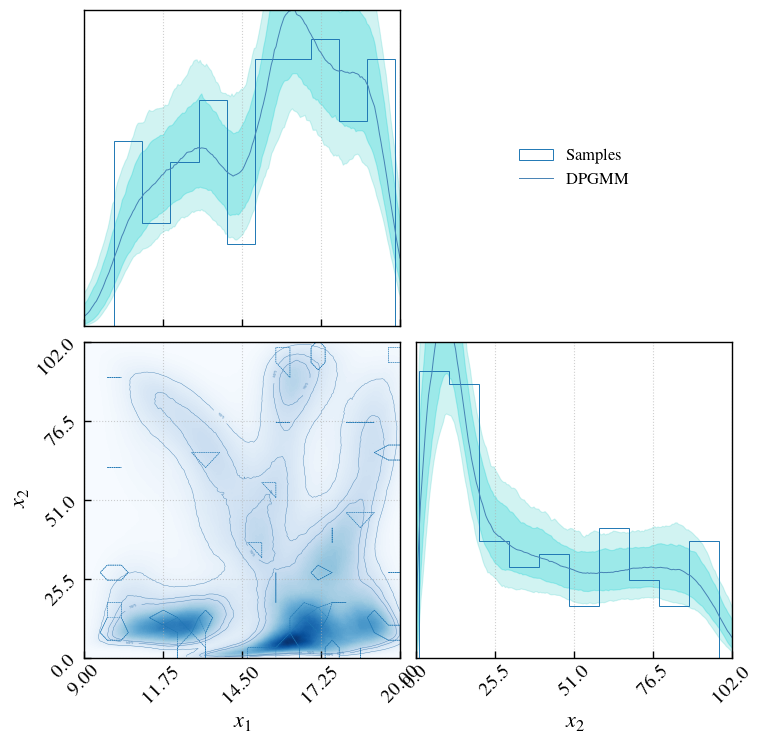

In [21]:
fig = plot_multidim(draws_2d,
                    samples = samples_aq,
                    save = False,
                    )

## single HDPGMM

In [8]:
n_post_samps = 100

single_event_posteriors = [st.norm(st.norm(a, s).rvs(), s).rvs(n_post_samps) 
                           for a, s in zip(a0_samp, np.random.uniform(1,3, size = len(a0_samp)))]

n_draws = 10
a_min = np.min(single_event_posteriors)-1
a_max = np.max(single_event_posteriors)+1
bounds = [[a_min, a_max]]

In [10]:
selfunc1d = lambda a : psel(a,0.2,20,0.1)

In [11]:
def inner_dp1d(event):
    """get DP draws for a single observation """
    draws = []
    mix = DPGMM(bounds, prior_pars = get_priors(bounds, samples = event))
    for _ in range(n_draws):
        draws.append(mix.density_from_samples(event))
    return draws

posteriors = Parallel(n_jobs=-1)(delayed(inner_dp1d)(event) for event in tqdm(single_event_posteriors))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [01:09<00:00,  1.44it/s]


In [12]:
# hierarchical for bhmf
hier_mix = HDPGMM(bounds, prior_pars = get_priors(bounds, samples = single_event_posteriors, hierarchical = True), selection_function=selfunc1d)
n_draws_hier = 10
hier_draws_func = lambda n: hier_mix.density_from_samples(posteriors)
hier_draws = Parallel(n_jobs=-1)(delayed(hier_draws_func)(n) for n in tqdm(range(n_draws_hier)))

100%|██████████| 10/10 [00:00<00:00, 7624.62it/s]


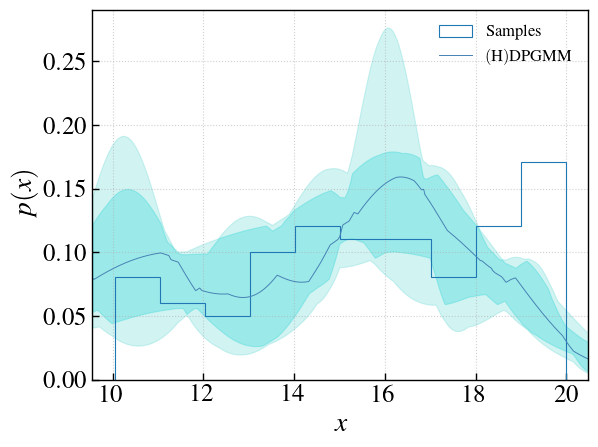

In [13]:
fig = plot_median_cr(hier_draws,
                     samples      = a0_samp,
                     show         = True,
                     hierarchical = True
                     )

## 2d HDPGMM

In [11]:
def gen_event_posteriors(true_param,smin,smax,n_post_samps = 101):
    # random sample a measurement about true param, then random sample measurement posterior
    single_event_posteriors = [st.norm(st.norm(a, s).rvs(), s).rvs(n_post_samps) 
                           for a, s in zip(true_param, np.random.uniform(smin,smax, size = len(true_param)))]
    # find posterior with negative value
    find_neg = lambda arr: np.array([i for i in range(len(arr)) if np.min(arr[i])<0])
    neg_ind = find_neg(single_event_posteriors)
    # print(neg_ind)
    # niter = 0
    while len(neg_ind) != 0:
        for i in neg_ind:
            s = np.random.uniform(smin,smax)
            a = true_param[i]
            single_event_posteriors[i] = st.norm(st.norm(a, s).rvs(), s).rvs(n_post_samps) 
        neg_ind = find_neg(single_event_posteriors)
        # niter+=1
    return single_event_posteriors

single_event_posteriors_a = gen_event_posteriors(a0_samp,1,3)
single_event_posteriors_q = gen_event_posteriors(q_samp,0.1,1)
single_event_posteriors_aq = np.stack([single_event_posteriors_a,single_event_posteriors_q],axis=2)

[print(np.min(x),np.max(x)) for x in [single_event_posteriors_a,single_event_posteriors_q]];

# for i in range(Nobs):
#     np.savetxt(f"/home/insepien/dftime/data/event/event_{i}.txt",single_event_posteriors_aq[i,:,:])

0.03683289725804961 31.789846787956026
0.28858204874261784 90.64732232934122


In [ ]:
n_draws = 10
a_min = 0
a_max = 40
q_min = 0
q_max = 100
bounds = [[a_min, a_max],[q_min,q_max]]

# DPGMM for each event
posteriors = []
def event_dp(event):
    draws = []
    mix_2dh = DPGMM(bounds, prior_pars = get_priors(bounds, samples = event,scale=3))
    for _ in range(n_draws):
        draws.append(mix_2dh.density_from_samples(event))
    return draws
# event posteriors
posteriors = Parallel(n_jobs=-1)(delayed(event_dp)(event) for event in tqdm(single_event_posteriors_aq))


100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


In [ ]:
def selfunc_hdp(AQ):
    """selection function for hdpgmm"""
    sep_kpc = AQ[:,0]
    q = AQ[:,1]
    return psel(sep_kpc,0.2,q,reso)

# hierarchical for bhmf
hier_mix = HDPGMM(bounds, 
                  prior_pars = get_priors(bounds, samples = single_event_posteriors_aq,hierarchical = True),
                  selection_function=selfunc_hdp
                    )
n_draws_hier = 3
hier_draws_2d = []

# for _ in tqdm(range(n_draws_hier)):
#     hier_draws_2d.append(hier_mix.density_from_samples(posteriors))
hdp = lambda n: hier_mix.density_from_samples(posteriors)
hdraws = Parallel(n_jobs=-1)(delayed(hdp)(n) for n in tqdm(range(n_draws_hier)))

100%|██████████| 3/3 [00:00<00:00, 1422.28it/s]


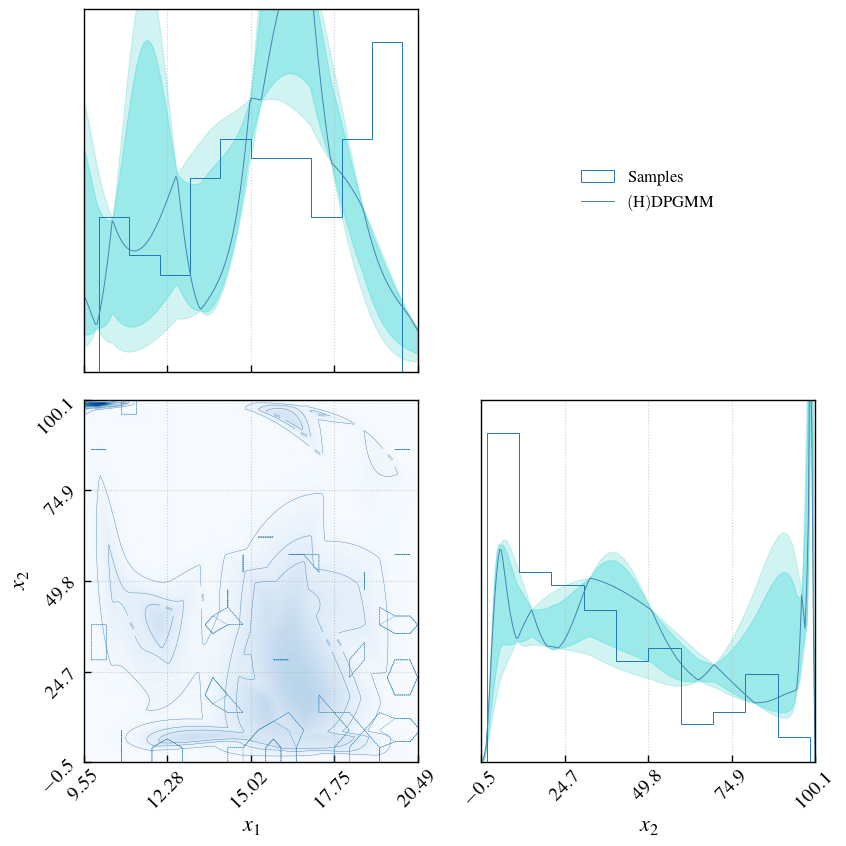

In [44]:
fig = plot_multidim(hdraws,
                    samples = samples_aq,
                    save = False,
                    hierarchical=True
                    )
fig.tight_layout()

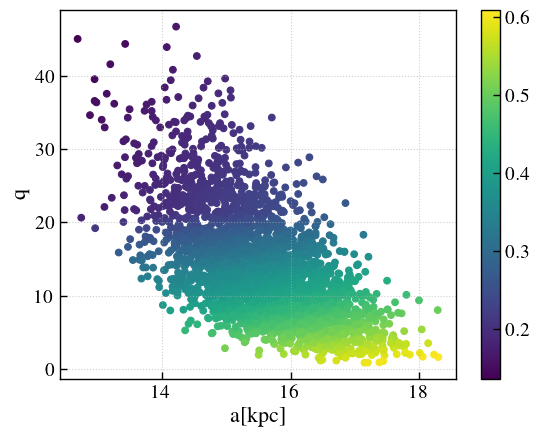

In [ ]:
from figaro.mixture import transform_from_probit
from scipy.stats import multivariate_normal as mn
m = hier_mix.mu_MC[0]
s = hier_mix.sigma_MC[0]
samps = mn(m,s).rvs(hier_mix.MC_draws)
samptrans = transform_from_probit(samps,hier_mix.bounds)
pselval =selfunc_hdp(samptrans)

plt.scatter(samptrans[:,0],samptrans[:,1],c=pselval)
plt.xlabel('a[kpc]')
plt.ylabel('q')
plt.colorbar();

## debug selfunc
selfunc yields nan probs. fixed by interpolating a=(0,200), q=(0,100)

In [ ]:
from figaro.load import load_density
import inspect
sepost = [load_density(f'/home/insepien/dftime_data/draws/draws_event_{i}.json') for i in range(5)]

In [15]:
from figaro.load import load_single_event
sepost_samp = [load_single_event(f'/home/insepien/dftime_data/events/event_{i}.txt') for i in range(100)]

In [23]:
sepost_samp = [sepost_samp[i][0] for i in range(100)]

In [26]:
def selfunc_hdp_debug(AQ):
    """selection function for hdpgmm"""
    sep_kpc = AQ[:,0]
    q = AQ[:,1]
    val = psel(sep_kpc, 0.2, q, reso)
    
    # Check if ANY values in this batch are problematic
    if np.any(val <= 1e-15) or np.any(np.isnan(val)):
        stack = inspect.stack()
        caller_name = stack[1].function 
        parent_name = stack[2].function if len(stack) > 2 else "Unknown"
        
        # Find exactly which rows in AQ are causing the zero
        bad_indices = np.where((val <= 1e-15) | (np.isnan(val)))[0]
        
        print(f"\n--- !!! SELF-FUNC WARNING !!! ---")
        print(f"Location: {parent_name} -> {caller_name}")
        print(f"Offending Coordinates (First 3):\n{AQ[bad_indices[:3]]}")
        print(f"Problematic Values: {val[bad_indices[:3]]}")
        
        # CRITICAL: Convert NaNs to 0 and then clip to a tiny floor
        # This keeps the math alive!
        val = np.nan_to_num(val, nan=0.0)
        return np.maximum(val, 1e-15)
        
    return val

# hierarchical for bhmf
bounds = [[0,40],[0,100]]
hier_mix = HDPGMM(bounds, 
                  prior_pars = get_priors(bounds, samples = sepost_samp,hierarchical = True),
                  selection_function=selfunc_hdp_debug
                    )
n_draws_hier = 100
hier_draws_2d = []

for _ in tqdm(range(n_draws_hier)):
    hier_draws_2d.append(hier_mix.density_from_samples(sepost))
# hdp = lambda n: hier_mix.density_from_samples(sepost)
# hier_draws_2d = Parallel(n_jobs=-1)(delayed(hdp)(n) for n in tqdm(range(n_draws_hier)))

100%|██████████| 100/100 [08:12<00:00,  4.93s/it]


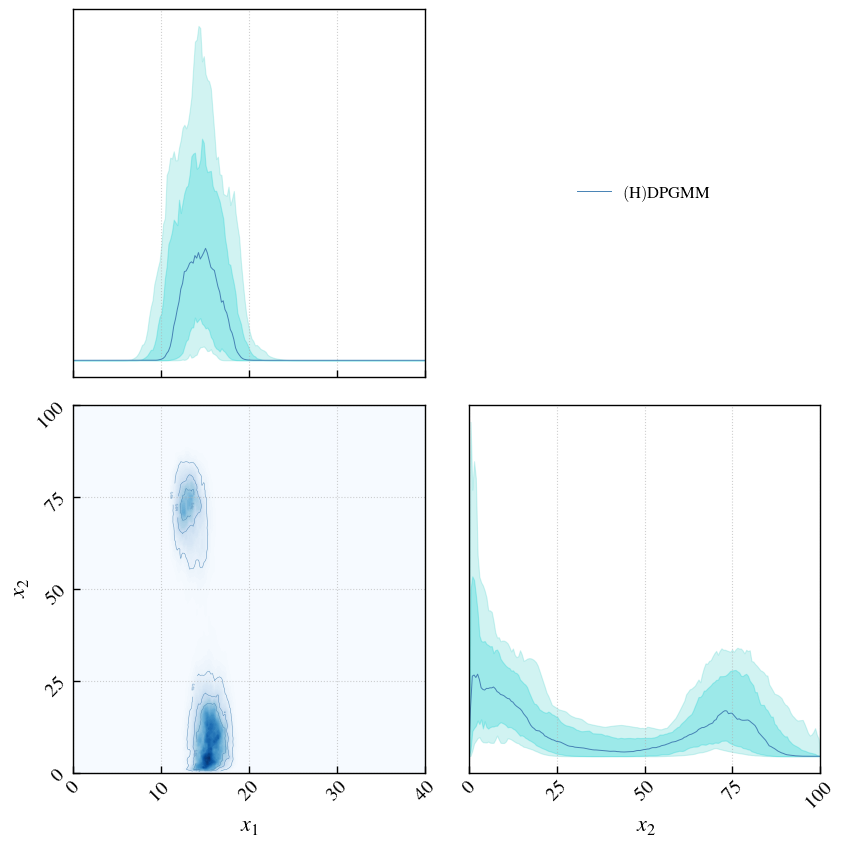

In [28]:
fig = plot_multidim(hier_draws_2d,
                    save = False,
                    hierarchical=True
                    )
fig.tight_layout()

## debug posterior sample

posterior of a exceed intrinsic bounds due to large Gaussian errors for each event s=(1,3)

In [ ]:
from figaro.load import load_single_event
sepost_samp = [load_single_event(f'/home/insepien/dftime_data/events/event_{i}.txt')[0] for i in range(100)]
allsamp = np.concatenate(sepost_samp)

from figaro.load import load_density
dens = load_density("draws_intrinsic_dftime_data.json")

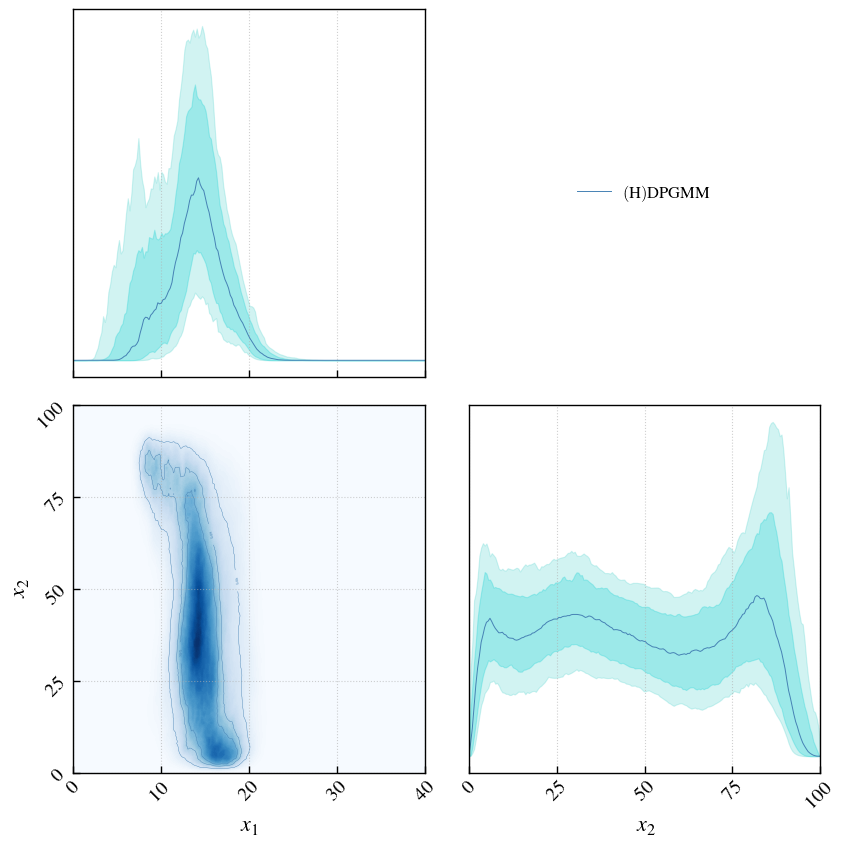

In [79]:
fig = plot_multidim(dens,
                    save = False,
                    hierarchical=True
                    )
fig.tight_layout()

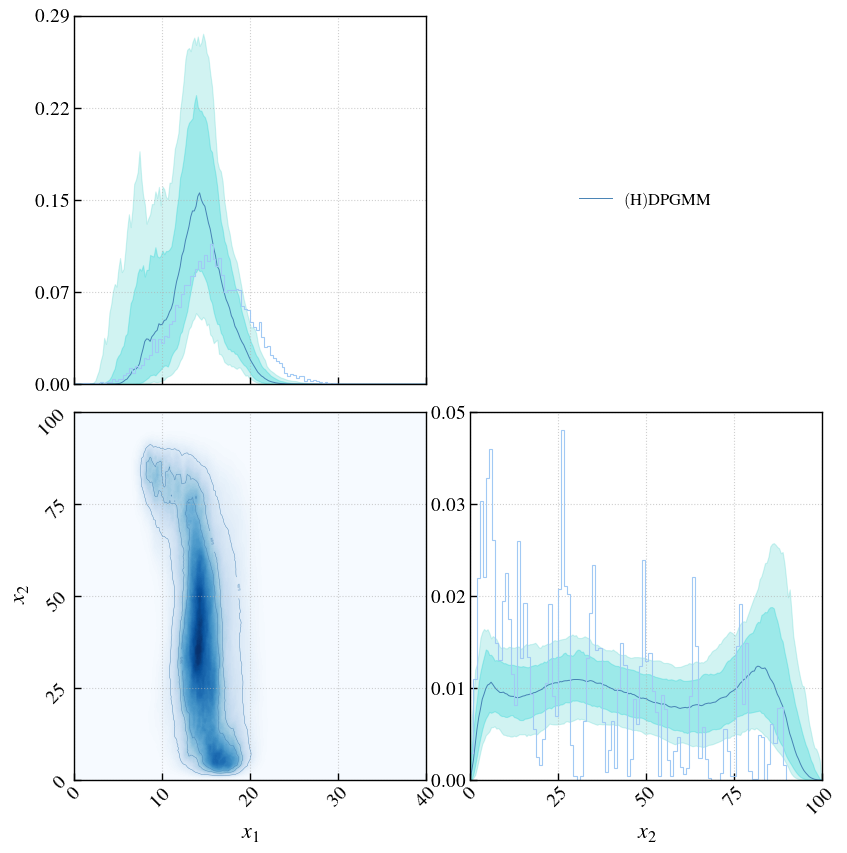

In [156]:
# make figure copy for easy edits
import copy
draft = copy.deepcopy(fig)

# plot stacked hist
ax = draft.get_axes()
ax[0].hist(allsamp[:,0],density=True,histtype='step')
ax[3].hist(allsamp[:,1],density=True,histtype='step')

# add ticks
for i in [0,3]:
    ylim = ax[i].get_ylim()
    # Create 5 ticks between min and max
    ticks = np.linspace(ylim[0], ylim[1], 5)

    ax[i].set_yticks(ticks)
    ax[i].set_yticklabels([f"{t:.2f}" for t in ticks])

draft.canvas.draw()
draft

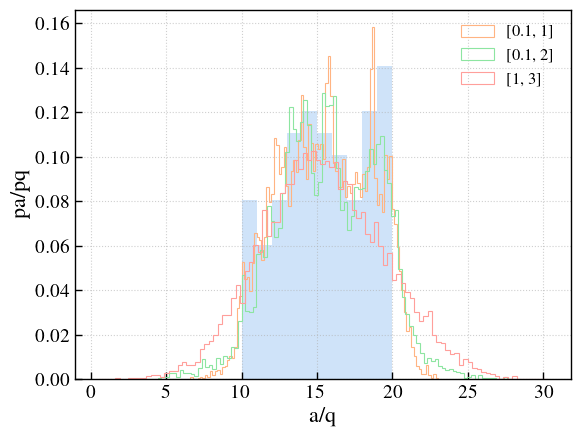

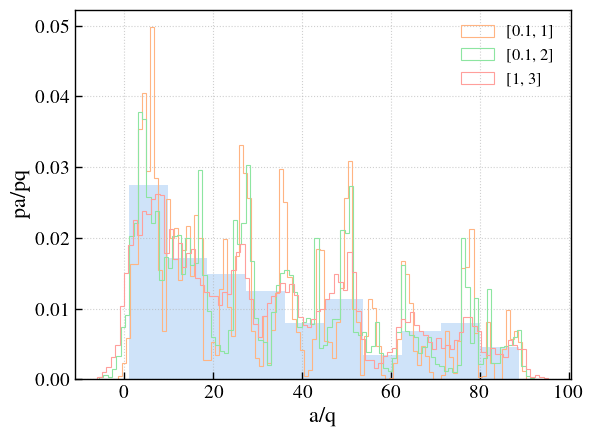

In [ ]:
def tp(accepted_q):
    """see how posterior errors affect density shape"""
    plt.figure()
    plt.hist(accepted_q,histtype='stepfilled',alpha=0.5)

    for sv in [[0.1,1],[0.1,2],[1,3]]:
        testp = [st.norm(st.norm(a, s).rvs(), s).rvs(101) 
                                for a, s in zip(accepted_q, np.random.uniform(sv[0],sv[1], size = len(accepted_q)))]

        testp_arr = np.concatenate(testp)

        plt.hist(testp_arr,label=f"{sv}");

    plt.xlabel("a/q")
    plt.ylabel('pa/pq')
    plt.legend();

tp(a0_samp)
tp(q_samp)